In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation, PillowWriter

In [68]:
# ==========================================
# 1. LOAD THE DATA
# ==========================================

df = pd.read_csv("play_2735.csv")

print("Rows:", len(df))
print("Frames:", df["frameId"].nunique())
print("Teams:", df["club"].dropna().unique())


Rows: 943
Frames: 41
Teams: <ArrowStringArray>
['PIT', 'NYJ', 'football']
Length: 3, dtype: str


In [69]:
# ==========================================
# 2. GET FRAMES AND TEAMS
# ==========================================

frames = sorted(df["frameId"].unique())

# Two Teams
teams = [
    team for team in df["club"].dropna().unique()
    if team != "football"
]

# Different colors
team_colors = {
    teams[0]: "blue",
    teams[1]: "red"
}

print("Number of frames:", len(frames))
print("Teams:", teams)

Number of frames: 41
Teams: ['PIT', 'NYJ']


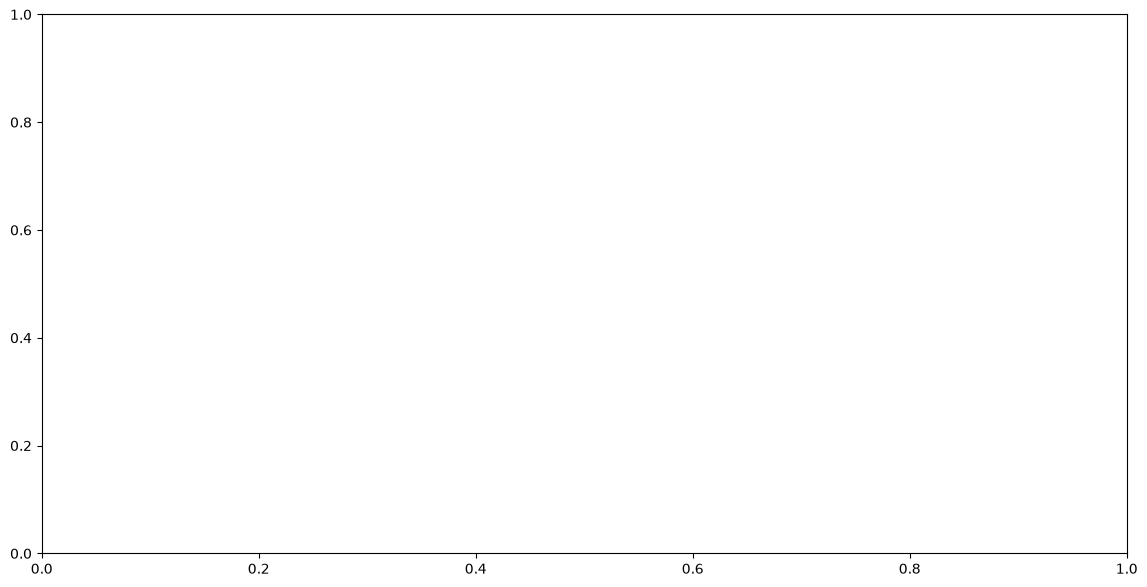

In [70]:
# ==========================================
# 3. CREATE THE FIGURE
# ==========================================

fig, ax = plt.subplots(figsize=(14, 7))

In [71]:
# ==========================================
# 4. ANIMATION FUNCTION
# ==========================================

def animate(frame):

    # Clear the previous frame
    ax.clear()

    # Get data for this frame
    frame_data = df[df["frameId"] == frame]

    #Field
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    ax.set_facecolor("forestgreen")

   #End Zones
    ax.axvspan(0, 10, color="darkblue", alpha=0.8)
    ax.axvspan(110, 120, color="darkred", alpha=0.8)

   #Sidelines
    ax.axhline(0, color="white", linewidth=3)
    ax.axhline(53.3, color="white", linewidth=3)
    ax.axvline(0, color="white", linewidth=3)
    ax.axvline(120, color="white", linewidth=3)

   #Goal Lines
    ax.axvline(10, color="white", linewidth=3)
    ax.axvline(110, color="white", linewidth=3)

   #Yard Lines
    for x in range(20, 110, 10):
        ax.axvline(
            x,
            color="white",
            linewidth=1.5
        )

    #5-yard lines
    for x in range(15, 110, 5):
        ax.axvline(
            x,
            color="white",
            linewidth=0.5,
            alpha=0.5
        )

    #Yard Numbers
    yard_numbers = {
        20: 10,
        30: 20,
        40: 30,
        50: 40,
        60: 50,
        70: 40,
        80: 30,
        90: 20,
        100: 10
    }

    for x, number in yard_numbers.items():

        # Bottom number
        ax.text(
            x,
            7,
            str(number),
            color="white",
            fontsize=18,
            fontweight="bold",
            ha="center",
            va="center"
        )

        # Top number
        ax.text(
            x,
            46,
            str(number),
            color="white",
            fontsize=18,
            fontweight="bold",
            ha="center",
            va="center",
            rotation=180
        )

   #Hash Marks
    for x in range(11, 110):

        ax.plot(
            [x, x],
            [23.3, 24.3],
            color="white",
            linewidth=0.5
        )

        ax.plot(
            [x, x],
            [29.0, 30.0],
            color="white",
            linewidth=0.5
        )

  #Label End Zones
    if len(teams) >= 2:

        ax.text(
            5,
            26.65,
            teams[0],
            color="white",
            fontsize=18,
            fontweight="bold",
            ha="center",
            va="center",
            rotation=90
        )

        ax.text(
            115,
            26.65,
            teams[1],
            color="white",
            fontsize=18,
            fontweight="bold",
            ha="center",
            va="center",
            rotation=270
        )

   #Players
    for team in teams:

        team_data = frame_data[
            frame_data["club"] == team
        ]

        ax.scatter(
            team_data["x"],
            team_data["y"],
            s=140,
            color=team_colors[team],
            edgecolor="white",
            linewidth=1.5,
            label=team,
            zorder=5
        )

       #Insert Jersey Numbers 
        for _, player in team_data.iterrows():

            if pd.notna(player["jerseyNumber"]):

                ax.text(
                    player["x"],
                    player["y"],
                    str(int(player["jerseyNumber"])),
                    color="white",
                    fontsize=7,
                    fontweight="bold",
                    ha="center",
                    va="center",
                    zorder=6
                )

  #Plot Football
    football = frame_data[
        frame_data["displayName"]
        .astype(str)
        .str.lower()
        == "football"
    ]

    if len(football) > 0:

        ax.scatter(
            football["x"],
            football["y"],
            s=80,
            color="brown",
            edgecolor="white",
            linewidth=1,
            marker="o",
            zorder=7
        )

  #Title
    ax.set_title(
        f"Game 2022100210 | Play 2735 | Frame {frame}",
        fontsize=16,
        fontweight="bold"
    )

#Legend
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=2
    )

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])

In [72]:
#CREATE THE ANIMATION
ani = FuncAnimation(
    fig,
    animate,
    frames=frames,
    interval=50,
    repeat=False
)

# SAVE AS GIF
ani.save(
    "play_2735.gif",
    writer=PillowWriter(fps=20)
)

print("Animation saved as play_2735.gif")

plt.show()

Animation saved as play_2735.gif
